# Decoding electrode QC on inflated brain

Sanity-check the electrodes that actually entered anatomical-ROI
lexicality decoding on the **Hammers** atlas.

- Channel list: union across Stimulus / Delay / Go / Response and
  Decision / Repeat in the current lexicality H5s
- Coordinates: Hammers `x_t, y_t, z_t` (cvs_avg35 template)
- Display: snap to pial, plot on **inflated**
- Color: decoding pool (`AIC`, `PIC`, `STG`, `SMC`, `MFG`)

The 3D view is **Plotly** in the browser (orbit / zoom / hover). This avoids
VTK windows and MNE/PyVista screenshots, which do not work interactively on
remote DCC. A standalone HTML is also written under `img/decode/` if the
notebook widget is awkward.

This is not the NMF Sensory / Sustain / Motor pool.

Style: [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).

In [2]:
%matplotlib inline

import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import pyvista as pv
from IPython.display import display
from scipy.spatial import cKDTree

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import img_dir

In [3]:
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
fontsize = 7
fontdict = dict(fontsize=fontsize)

red = "#A9373B"
blue = "#2369BD"
stg_color = "#20B2AA"
smc_color = "#6A5ACD"
mfg_color = "#666666"

ROI_ORDER = ["AIC", "PIC", "STG", "SMC", "MFG"]
ROI_COLOR = {
    "AIC": red,
    "PIC": blue,
    "STG": stg_color,
    "SMC": smc_color,
    "MFG": mfg_color,
}

BIDS_ROOT = Path("/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS")
DECODE_ROOT = BIDS_ROOT / "derivatives" / "decoding(bipolar)"
PARC_ROOT = BIDS_ROOT / "derivatives" / "parcellation"
RECON_DIR = Path("/cwork/ns458/ECoG_Recon")
FS_SUBJECT = "cvs_avg35_inMNI152"

DATATYPE = "lexicality"
PHASES = ("Stimulus", "Delay", "Go", "Response")
DESCRIPTIONS = ("Decision", "Repeat")
HEMIS = ("l", "r")

EXPECTED = {
    "AIC": {"AIC"},
    "PIC": {"PIC"},
    "STG": {"STGa", "STGp"},
    "SMC": {"PrG", "PoG"},
    "MFG": {"MFG"},
}

export_dir = img_dir("decode")

## Load decoding H5 channels and join Hammers coordinates

In [4]:
def _as_str(value) -> str:
    return value.decode() if isinstance(value, bytes) else str(value)


def iter_decoding_h5s():
    for roi in ROI_ORDER:
        for hemi in HEMIS:
            folder = DECODE_ROOT / f"sub-{roi}{hemi}" / DATATYPE
            if not folder.exists():
                continue
            for phase in PHASES:
                for description in DESCRIPTIONS:
                    name = (
                        f"sub-{roi}{hemi}_task-LexicalDelay_"
                        f"proc-{phase}_desc-{description}_highgamma.h5"
                    )
                    path = folder / name
                    if path.exists():
                        yield roi, hemi, phase, description, path


rows = []
for roi, hemi, phase, description, path in iter_decoding_h5s():
    with h5py.File(path, "r") as f:
        channels = [_as_str(ch) for ch in f["channel"][:]]
        atlas = _as_str(f.attrs.get("atlas", ""))
        source = _as_str(f.attrs.get("input_datatype", ""))
    for channel in channels:
        rows.append(
            {
                "decode_roi": roi,
                "hemi": hemi.upper(),
                "phase": phase,
                "description": description,
                "channel": channel,
                "atlas": atlas,
                "input_datatype": source,
            }
        )

usage = pd.DataFrame(rows)
if usage.empty:
    raise RuntimeError(f"No lexicality H5s under {DECODE_ROOT}")

electrodes = (
    usage.groupby(["decode_roi", "hemi", "channel"], as_index=False)
    .agg(
        n_files=("phase", "size"),
        phases=("phase", lambda s: ",".join(sorted(set(s)))),
        atlas=("atlas", "first"),
        input_datatype=("input_datatype", "first"),
    )
)

parc = pd.concat(
    (pd.read_csv(p) for p in sorted(PARC_ROOT.glob("sub-*/bipolar/sub-*_hammers.csv"))),
    ignore_index=True,
)
parc = parc.rename(columns={"name": "channel", "roi": "hammers_roi"})

plot_df = electrodes.merge(
    parc[["channel", "subject", "hammers_roi", "mix", "hemi", "x_t", "y_t", "z_t"]],
    on="channel",
    how="left",
    suffixes=("", "_parc"),
)

missing = int(plot_df["x_t"].isna().sum())
print(f"unique electrodes in lexicality H5s: {len(electrodes)}")
print(f"missing Hammers coords: {missing}")
print("H5 atlas values:", sorted(electrodes["atlas"].dropna().unique()))
display(electrodes.groupby(["decode_roi", "hemi"]).size().unstack(fill_value=0))

unique electrodes in lexicality H5s: 663
missing Hammers coords: 0
H5 atlas values: ['hammers']


hemi,L,R
decode_roi,,
AIC,50,38
MFG,87,78
PIC,44,30
SMC,51,35
STG,137,113


## Decoding pool vs Hammers ROI

The cross-tab is the hard check. Off-pool rows mean the H5 channel list
does not match the Hammers definition used by `prepare_decoding_dataset.py`.

In [5]:
census = (
    plot_df.dropna(subset=["hammers_roi"])
    .groupby(["decode_roi", "hammers_roi", "mix"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["decode_roi", "n"], ascending=[True, False])
)
display(census)

cross = (
    plot_df.dropna(subset=["hammers_roi"])
    .pivot_table(
        index="decode_roi",
        columns="hammers_roi",
        values="channel",
        aggfunc="nunique",
        fill_value=0,
    )
    .reindex(index=ROI_ORDER)
)
display(cross)

leak = plot_df.dropna(subset=["hammers_roi"]).copy()
leak["expected"] = leak.apply(
    lambda row: row["hammers_roi"] in EXPECTED.get(row["decode_roi"], set()),
    axis=1,
)
off_pool = (
    leak.loc[
        ~leak["expected"],
        ["channel", "decode_roi", "hammers_roi", "mix", "hemi"],
    ]
    .drop_duplicates()
    .sort_values(["decode_roi", "hammers_roi", "channel"])
)
print(f"off-pool electrodes: {len(off_pool)}")
display(off_pool)

,decode_roi,hammers_roi,mix,n
0,AIC,AIC,False,88
1,MFG,MFG,False,165
2,PIC,PIC,False,74
4,SMC,PrG,False,59
3,SMC,PoG,False,27
6,STG,STGp,False,222
5,STG,STGa,False,28


hammers_roi,AIC,MFG,PIC,PoG,PrG,STGa,STGp
decode_roi,,,,,,,
AIC,88,0,0,0,0,0,0
PIC,0,0,74,0,0,0,0
STG,0,0,0,0,0,28,222
SMC,0,0,0,27,59,0,0
MFG,0,165,0,0,0,0,0


off-pool electrodes: 0


,channel,decode_roi,hammers_roi,mix,hemi


## 3D brains

Color is the **decoding pool**: which H5 the channel was taken from
(`AIC` / `PIC` / `STG` / `SMC` / `MFG`).

**Inflated** opens the sulci so buried contacts are easier to see.
**Pial** is the real cortical surface — use that to judge whether a
point is really AIC / STG / MFG.

Drag to orbit, scroll to zoom, hover for channel name. HTML copies
are written under `img/decode/`.


In [6]:
surf = {}
for hemi in ("lh", "rh"):
    pial, pial_faces = mne.read_surface(RECON_DIR / FS_SUBJECT / "surf" / f"{hemi}.pial")
    inflated, inf_faces = mne.read_surface(RECON_DIR / FS_SUBJECT / "surf" / f"{hemi}.inflated")

    def _decimate(verts, faces):
        mesh = pv.PolyData(verts, np.hstack([np.full((len(faces), 1), 3, dtype=int), faces]))
        return mesh.triangulate().decimate(0.88)

    surf[hemi] = {
        "pial": pial,
        "inflated": inflated,
        "tree": cKDTree(pial),
        "pial_mesh": _decimate(pial, pial_faces),
        "inflated_mesh": _decimate(inflated, inf_faces),
        "shift_x": 0.0,
    }

# Inflated L/R share the same RAS box and fuse at the midline unless
# pulled apart. Pial already has a natural interhemispheric gap.
lh_max = float(surf["lh"]["inflated_mesh"].points[:, 0].max())
rh_min = float(surf["rh"]["inflated_mesh"].points[:, 0].min())
hemi_gap = 25.0
shift = max(0.0, (lh_max - rh_min + hemi_gap) / 2.0)
surf["lh"]["shift_x"] = -shift
surf["rh"]["shift_x"] = shift
print(f"inflated hemisphere x-shift: ±{shift:.1f} mm (gap {hemi_gap:.0f} mm)")


def to_surface(coords: np.ndarray, hemi: str, surface: str) -> np.ndarray:
    if coords.size == 0:
        return coords.reshape(0, 3)
    _, idx = surf[hemi]["tree"].query(coords)
    if surface == "inflated":
        xyz = surf[hemi]["inflated"][idx].copy()
        xyz[:, 0] += surf[hemi]["shift_x"]
        return xyz
    if surface == "pial":
        return surf[hemi]["pial"][idx].copy()
    raise ValueError(f"Unknown surface: {surface}")


def _hex_to_rgb(color) -> str:
    if isinstance(color, str) and color.startswith("#"):
        return color
    rgb = np.asarray(color[:3], dtype=float)
    if rgb.max() <= 1.0:
        rgb = rgb * 255.0
    return "rgb({},{},{})".format(*np.clip(rgb, 0, 255).astype(int))


def _mesh3d(hemi: str, surface: str) -> go.Mesh3d:
    mesh = surf[hemi][f"{surface}_mesh"]
    faces = mesh.faces.reshape(-1, 4)
    if not np.all(faces[:, 0] == 3):
        raise ValueError(f"{hemi} {surface} mesh is not all triangles")
    faces = faces[:, 1:]
    shift = surf[hemi]["shift_x"] if surface == "inflated" else 0.0
    return go.Mesh3d(
        x=mesh.points[:, 0] + shift,
        y=mesh.points[:, 1],
        z=mesh.points[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color="#d8d8d8",
        opacity=0.22,
        flatshading=True,
        lighting=dict(ambient=0.7, diffuse=0.5, specular=0.05),
        name=f"{hemi} {surface}",
        hoverinfo="skip",
        showlegend=False,
    )


def show_interactive_brain(
    df: pd.DataFrame,
    color_col: str,
    color_map: dict,
    title: str,
    html_name: str,
    surface: str = "inflated",
):
    """Orbitable brain in the notebook, plus a standalone HTML copy."""
    if surface not in {"inflated", "pial"}:
        raise ValueError(f"Unknown surface: {surface}")
    ready = df.dropna(subset=["x_t", "y_t", "z_t"]).drop_duplicates("channel").copy()
    traces = [_mesh3d("lh", surface), _mesh3d("rh", surface)]

    for hemi in ("lh", "rh"):
        side = ready.loc[ready["x_t"].lt(0) if hemi == "lh" else ready["x_t"].gt(0)]
        if side.empty:
            continue
        xyz = to_surface(side[["x_t", "y_t", "z_t"]].to_numpy(float), hemi, surface)
        for roi, color in color_map.items():
            mask = side[color_col].to_numpy() == roi
            if not mask.any():
                continue
            pts = xyz[mask]
            meta = side.loc[mask]
            hover = [
                f"{row.channel}<br>decode: {row.decode_roi}<br>Hammers: {row.hammers_roi}"
                f"<br>mix: {row.mix}"
                for row in meta.itertuples()
            ]
            traces.append(
                go.Scatter3d(
                    x=pts[:, 0],
                    y=pts[:, 1],
                    z=pts[:, 2],
                    mode="markers",
                    marker=dict(size=4, color=_hex_to_rgb(color), line=dict(width=0)),
                    name=str(roi),
                    text=hover,
                    hoverinfo="text",
                    legendgroup=str(roi),
                    showlegend=hemi == "lh",
                )
            )

    fig = go.Figure(data=traces)
    fig.update_layout(
        title=dict(text=title, font=dict(size=13)),
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode="data",
            bgcolor="white",
            camera=dict(eye=dict(x=-1.6, y=0.1, z=0.35)),
        ),
        paper_bgcolor="white",
        legend=dict(orientation="h", y=-0.02, font=dict(size=11)),
        margin=dict(l=0, r=0, t=40, b=0),
        height=640,
    )
    html_path = export_dir / html_name
    fig.write_html(html_path, include_plotlyjs="cdn", full_html=True)
    print(f"wrote {html_path}")
    fig.show()
    return fig


inflated hemisphere x-shift: ±59.0 mm (gap 25 mm)


In [7]:
ready = plot_df.dropna(subset=["x_t", "y_t", "z_t"]).drop_duplicates("channel")
print(f"electrodes with template coords: {len(ready)}")

fig = show_interactive_brain(
    ready,
    color_col="decode_roi",
    color_map=ROI_COLOR,
    title="Inflated · color = decoding pool (which H5 the channel came from)",
    html_name="lexicality_electrodes_inflated_by_decode_roi.html",
    surface="inflated",
)

electrodes with template coords: 663
wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/decode/lexicality_electrodes_inflated_by_decode_roi.html


## Pial (not inflated)

Same electrodes and the same decoding-pool colors, on the real
cortical surface.


In [8]:
fig = show_interactive_brain(
    ready,
    color_col="decode_roi",
    color_map=ROI_COLOR,
    title="Pial · color = decoding pool (which H5 the channel came from)",
    html_name="lexicality_electrodes_pial_by_decode_roi.html",
    surface="pial",
)


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/decode/lexicality_electrodes_pial_by_decode_roi.html


## Shrinkage-LDA lexicality (functional clusters + STG)

The 3D panels above are the **anatomical** decoding pools (AIC / PIC / STG / SMC / MFG).
This section is the **new** time-resolved pipeline from SHI-39: shrinkage LDA,
five time bins, pooled out-of-fold AUC, word-level permutation (5000),
`StratifiedGroupKFold` on stimulus identity.

ROIs are the k=3 NMF clusters (Sensory / Sustain / Motor) plus STGl as a
positive control. Phases are Stimulus and Delay only (Go / Response held back).
Chance is 0.5. Spoken-word duration is **0.42–0.76 s** (mean 0.60 s).
The Stimulus panel marks that range as a grey I-beam (工) above the
significance bars. Delay t = 0 is word offset.

Results live in `results/decoding/LexicalDelay/sub-{ROI}/(decode)(resolved)(lda)lexicality/`.
Style matches `src/decoding/summarize_resolved_lda.py` / `plot_phase_accuracy`.


In [9]:
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter1d

from src.paths import RESULTS_ROOT, save_svg

gold = "#C4A35A"
LDA_ROI_COLOR = {
    "Sensory": blue,
    "Sustain": red,
    "Motor": gold,
    "STG": stg_color,
}
LDA_HUE_ORDER = ["Sensory", "Sustain", "Motor", "STG"]
LDA_ROIS = ["Sensory", "Sustain", "Motor", "STGl"]
LDA_PHASES = ["Stimulus", "Delay"]
LDA_DESCRIPTIONS = ["Repeat", "Decision"]
CHANCE_AUC = 0.5
SMOOTH_SIGMA = 2
BAR_PAD = 0.01
BAR_HEIGHT = 0.02
YLIM_PAD = 0.1
# CORRECT Auditory_stim duration, LexicalDelay events (n=3245).
STIM_DUR_MIN = 0.42
STIM_DUR_MAX = 0.76


def lda_result_path(roi, phase, description, datatype="lexicality", band="highgamma"):
    folder = (
        RESULTS_ROOT / "decoding" / "LexicalDelay" / f"sub-{roi}"
        / f"(decode)(resolved)(lda){datatype}"
    )
    matches = sorted(folder.glob(f"sub-{roi}_proc-{phase}_*desc-{description}_{band}.h5"))
    if not matches:
        return None
    if len(matches) > 1:
        raise ValueError(f"Expected one result, found {[str(m) for m in matches]}")
    return matches[0]


def read_lda_result(path, roi, phase, description):
    display_roi = (
        roi[:-1] if roi.endswith(("l", "r")) and roi not in LDA_ROI_COLOR else roi
    )
    with h5py.File(path, "r") as stream:
        time = stream["time"][:]
        auc = stream["auc"][:]
        frame = pd.DataFrame({
            "time": time,
            "auc": gaussian_filter1d(auc, sigma=SMOOTH_SIGMA, mode="nearest"),
            "auc_raw": auc,
            "mask": np.asarray(stream["mask"][:]).astype(bool).ravel(),
            "p_value": stream["p_values"][:],
        })
        frame["roi"] = display_roi
        frame["phase"] = phase
        frame["description"] = description
        frame["n_channels"] = int(stream.attrs["n_channels"])
        frame["n_perm"] = int(stream.attrs["n_perm"])
    return frame


def significant_windows(time_points, mask):
    if not mask.any():
        return []
    edges = np.flatnonzero(np.diff(np.concatenate(([0], mask.view(np.int8), [0]))))
    return [
        (round(float(time_points[start]), 3), round(float(time_points[stop - 1]), 3))
        for start, stop in zip(edges[::2], edges[1::2])
    ]


lda_frames, lda_missing = [], []
for description in LDA_DESCRIPTIONS:
    for roi in LDA_ROIS:
        for phase in LDA_PHASES:
            target = lda_result_path(roi, phase, description)
            if target is None:
                lda_missing.append(f"{roi}/{phase}/{description}")
                continue
            lda_frames.append(read_lda_result(target, roi, phase, description))

if lda_missing:
    print("missing:", ", ".join(lda_missing))
lda_scores = pd.concat(lda_frames, ignore_index=True) if lda_frames else pd.DataFrame()

rows = []
for (roi, phase, description), group in lda_scores.groupby(
    ["roi", "phase", "description"], sort=False
):
    group = group.sort_values("time")
    windows = significant_windows(group["time"].values, group["mask"].values.astype(bool))
    raw = group["auc_raw"].values
    rows.append({
        "roi": roi,
        "phase": phase,
        "description": description,
        "n_channels": int(group["n_channels"].iloc[0]),
        "peak_auc": round(float(raw.max()), 3),
        "peak_t": round(float(group["time"].values[int(raw.argmax())]), 2),
        "sig_windows": windows or "—",
    })
pd.DataFrame(rows)


,roi,phase,description,n_channels,peak_auc,peak_t,sig_windows
0,Sensory,Stimulus,Repeat,16,0.649,0.52,—
1,Sensory,Delay,Repeat,14,0.624,-0.17,—
2,Sustain,Stimulus,Repeat,30,0.751,1.27,"[(0.58, 0.85), (1.15, 1.48)]"
3,Sustain,Delay,Repeat,30,0.707,0.28,"[(0.25, 0.49), (0.64, 0.88)]"
4,Motor,Stimulus,Repeat,18,0.608,0.52,—
5,Motor,Delay,Repeat,20,0.604,0.19,—
6,STG,Stimulus,Repeat,85,0.798,0.64,"[(0.4, 1.48)]"
7,STG,Delay,Repeat,92,0.758,0.25,"[(-0.17, 0.85)]"
8,Sensory,Stimulus,Decision,16,0.585,1.45,—
9,Sensory,Delay,Decision,14,0.579,1.33,—


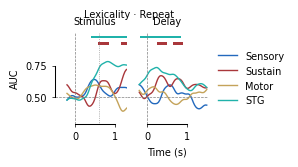

/hpc/group/coganlab/nanlinshi/insula-functional/img/decode/qc_lda_lexicality_Repeat.svg


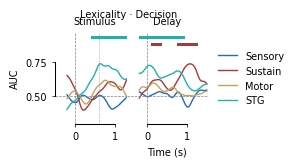

/hpc/group/coganlab/nanlinshi/insula-functional/img/decode/qc_lda_lexicality_Decision.svg


In [10]:
def mark_word_duration(ax, tmin, tmax, y0, y1):
    """I-beam (工) above the significance stack: spoken-word duration range."""
    ymid = 0.5 * (y0 + y1)
    kw = dict(color="0.45", clip_on=False, zorder=5, solid_capstyle="butt")
    ax.plot([tmin, tmax], [ymid, ymid], lw=1.25, **kw)
    for t in (tmin, tmax):
        ax.plot([t, t], [y0, y1], lw=0.75, **kw)


def plot_phase_auc(scores, phases, hue_order, xlim=(-0.5, 1.5)):
    roi_colors = [LDA_ROI_COLOR[roi] for roi in hue_order]
    values = scores["auc"].dropna()
    ymin = max(0.0, float(values.min()) - YLIM_PAD)
    ymax = float(values.max()) + YLIM_PAD
    dur_y0 = ymax + BAR_PAD + len(hue_order) * (BAR_HEIGHT + 0.005)
    dur_y1 = dur_y0 + BAR_HEIGHT * 2.5
    y_top = dur_y1 + 0.025
    n_phases = len(phases)
    legend_panel = n_phases - 1
    fig, axes = plt.subplots(1, n_phases, figsize=(2.5 * n_phases * cm, 3 * cm))
    if n_phases == 1:
        axes = [axes]
    plt.subplots_adjust(wspace=-0.1)

    for j, phase in enumerate(phases):
        ax = axes[j]
        subset = scores[scores.phase == phase]
        sns.lineplot(
            data=subset, x="time", y="auc", hue="roi",
            palette=roi_colors, hue_order=hue_order,
            lw=1, ax=ax, legend=(j == legend_panel),
        )
        ax.set_autoscale_on(False)
        ax.margins(y=0)
        for k, roi in enumerate(hue_order):
            roi_data = subset[subset.roi == roi].sort_values("time")
            if roi_data.empty or not roi_data["mask"].any():
                continue
            offset = k * (BAR_HEIGHT + 0.005)
            ax.fill_between(
                roi_data["time"].values,
                ymax + BAR_PAD + offset,
                ymax + BAR_PAD + BAR_HEIGHT + offset,
                where=roi_data["mask"].values,
                color=roi_colors[k], alpha=1, step="mid", linewidth=0,
            )
        if phase == "Stimulus":
            mark_word_duration(ax, STIM_DUR_MIN, STIM_DUR_MAX, dur_y0, dur_y1)

    for j, phase in enumerate(phases):
        ax = axes[j]
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.axvline(x=0, color="gray", linestyle="--", lw=0.5)
        ax.axhline(y=CHANCE_AUC, color="gray", linestyle="--", lw=0.5)
        ax.set_xlim(*xlim)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(phase.capitalize(), fontsize=fontsize)
        if j == 0:
            ax.set_ylabel("AUC", fontsize=fontsize)

    axes[n_phases // 2].set_xlabel("Time (s)", fontsize=fontsize)
    if axes[legend_panel].get_legend() is not None:
        axes[legend_panel].legend(
            fontsize=fontsize, frameon=False,
            loc="center left", bbox_to_anchor=(1.02, 0.5),
        )

    for ax in axes:
        ax.set_ylim(ymin, y_top)
        ax.set_ybound(ymin, y_top)
    axes[0].yaxis.set_major_locator(MaxNLocator(nbins=3))
    ticks = axes[0].get_yticks()
    axes[0].set_yticks(ticks[(ticks >= ymin) & (ticks <= ymax)])
    for ax in axes[1:]:
        ax.set_yticks([])
    for ax in axes:
        sns.despine(ax=ax, trim=True, offset=0.1)
    for ax in axes[1:]:
        ax.spines["left"].set_visible(False)
        ax.set_ylabel("")
    axes[0].yaxis.set_tick_params(labelleft=True)
    axes[0].yaxis.set_visible(True)
    return fig, axes


lda_out = img_dir("decode")
for description in LDA_DESCRIPTIONS:
    subset = lda_scores[lda_scores.description == description]
    if subset.empty:
        print(f"{description}: no results")
        continue
    hue_order = [roi for roi in LDA_HUE_ORDER if roi in set(subset["roi"])]
    fig, _ = plot_phase_auc(subset, LDA_PHASES, hue_order)
    fig.suptitle(f"Lexicality · {description}", fontsize=fontsize, y=1.08)
    svg = save_svg(
        fig, lda_out / f"qc_lda_lexicality_{description}", close=False,
    )
    display(fig)
    plt.close(fig)
    print(svg)
